# imports

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Functions


### SMA 

In [56]:
def SMA(stock, w:int):
    stock = stock['close'].rolling(window=w).mean()

    return stock

# Main

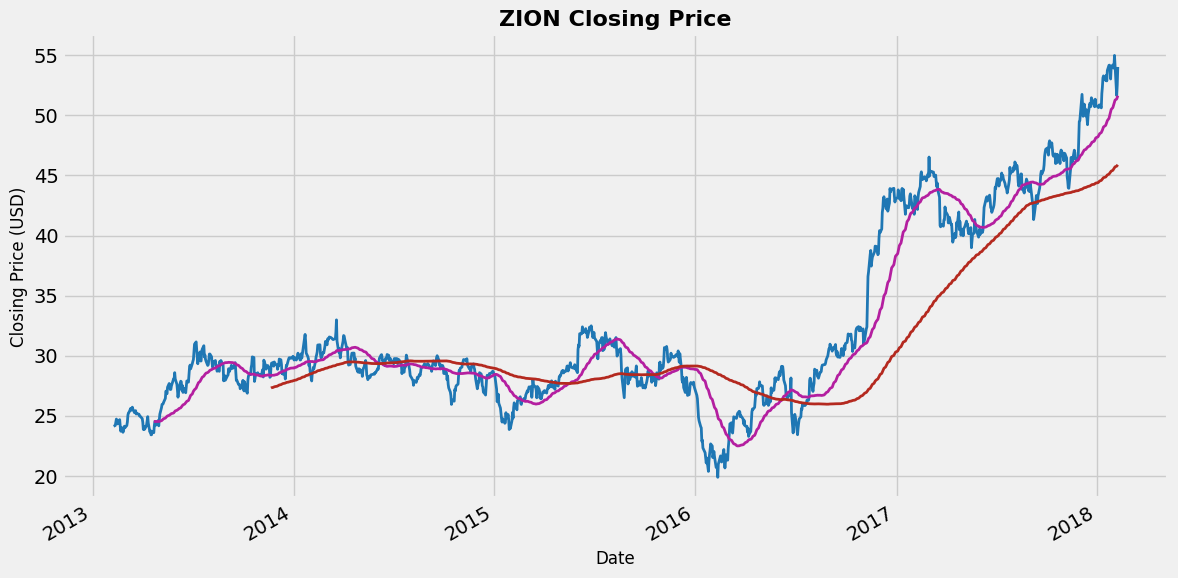

In [ ]:
zion = pd.read_csv('./all_stocks_5yr.csv')
zion = zion[ zion['Name'] == 'ZION' ].copy()        

zion['date'] = pd.to_datetime(zion['date'])

plt.style.use('fivethirtyeight')

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(zion['date'], zion['close'], color='#1f77b4', linewidth=2, label = 'Closing Price')     # closing price

ax.set_title('ZION Closing Price', fontsize=16, fontweight='bold')                                # format of the graph
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Closing Price (USD)', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()

zion['SMA50'] = SMA(zion, 50)                                                                     #SMA 50
zion['SMA200'] = SMA(zion, 200)                                                                   #SMA 200

ax.plot(zion['date'], zion['SMA50'], color = "#b41fa0", label = 'SMA50', linewidth=2)           #plot SMAs
ax.plot(zion['date'], zion['SMA200'], color = "#b4291f", label = 'SMA200', linewidth=2)

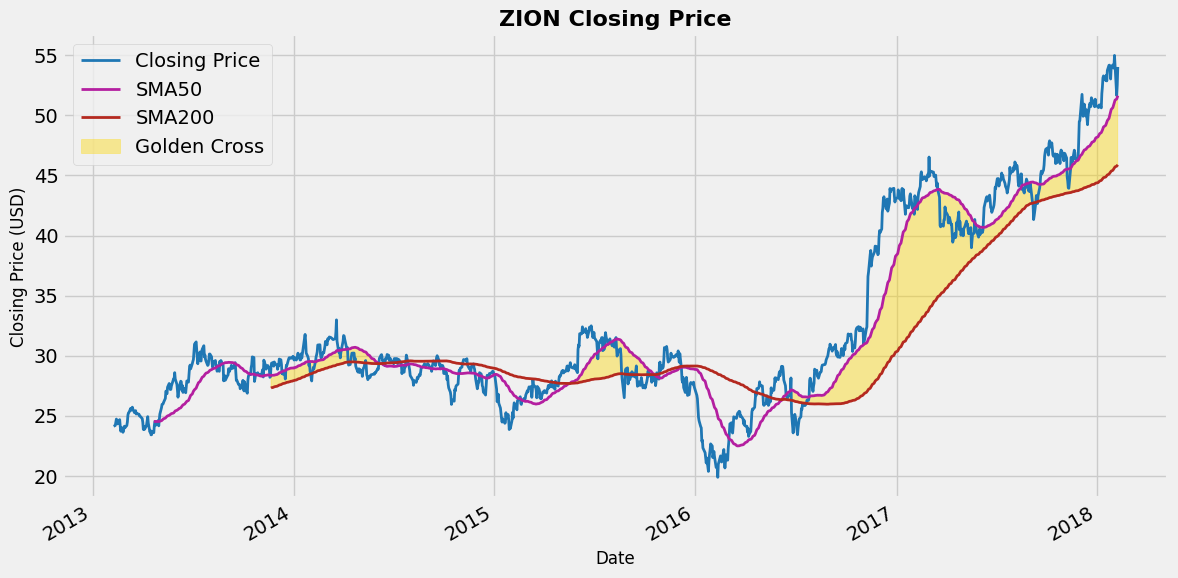

In [58]:
ax.fill_between(
    zion['date'], 
    zion['SMA50'], 
    zion['SMA200'], 
    color="gold", 
    alpha=0.4, 
    label='Golden Cross', 
    interpolate=True, 
    where=(zion['SMA50'] > zion['SMA200']))

ax.legend()

fig
